# LIV Golf — Team Performance Tracking

Analyzes team-level results across all LIV Golf seasons (2022–2026).
Builds aggregated team event scores, season summaries, scoring trends,
within-team contribution analysis, and a cross-event result heatmap.

**Outputs:**
- `team_event_results.csv` — team aggregate score + rank per event
- `team_season_summary.csv` — wins, podiums, avg rank, avg score per team per season

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import seaborn as sns
from pathlib import Path

DATA_DIR  = Path('../../02_player_dashboard/data')
OUT_DIR   = Path('.')

TEAM_COLORS = {
    'Crushers GC':          '#e74c3c',
    'Legion XIII':          '#8e44ad',
    'RangeGoats GC':        '#27ae60',
    'Torque GC':            '#f39c12',
    'HyFlyers GC':          '#2980b9',
    'Ripper GC':            '#16a085',
    'Cleeks Golf Club':     '#2c3e50',
    'Smash GC':             '#c0392b',
    'Majesticks Golf Club': '#7f8c8d',
    'Fireballs GC':         '#e67e22',
    'Southern Guards GC':   '#1abc9c',
    'Korean Golf Club':     '#3498db',
    '4Aces GC':             '#f1c40f',
    'Wild Card':            '#bdc3c7',
}

SHORT_NAMES = {
    'Crushers GC':          'Crushers',
    'Legion XIII':          'Legion XIII',
    'RangeGoats GC':        'RangeGoats',
    'Torque GC':            'Torque',
    'HyFlyers GC':          'HyFlyers',
    'Ripper GC':            'Ripper',
    'Cleeks Golf Club':     'Cleeks',
    'Smash GC':             'Smash',
    'Majesticks Golf Club': 'Majesticks',
    'Fireballs GC':         'Fireballs',
    'Southern Guards GC':   'Southern Guards',
    'Korean Golf Club':     'Korean GC',
    '4Aces GC':             '4Aces',
    'Wild Card':            'Wild Card',
}

plt.rcParams.update({
    'figure.facecolor': '#0e0e1a',
    'axes.facecolor':   '#0e0e1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
print('Setup complete.')

Setup complete.


## Cell 2 — Load & clean event results

In [2]:
raw = pd.read_csv(DATA_DIR / 'liv_event_results.csv', low_memory=False)

# ── Junk row filter ────────────────────────────────────────────────────────────
junk = (
    raw['playerName'].isna() |
    raw['playerName'].str.startswith('(', na=True) |
    raw['playerName'].str.strip().eq('- - - - - -') |
    (raw['playerName'].str.len() <= 3)
)
df = raw[~junk].copy()

# ── Clean player names (strip trailing " -" for withdrawals) ──────────────────
df['playerName'] = df['playerName'].str.strip().str.replace(r'\s*-\s*$', '', regex=True)

# ── Numeric coercions ─────────────────────────────────────────────────────────
for col in ['R1', 'R2', 'R3', 'total_to_par', 'year']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['position'] = pd.to_numeric(
    df['position'].astype(str).str.replace(r'^T', '', regex=True),
    errors='coerce'
)

# ── Drop rows with no team or no score ────────────────────────────────────────
df = df[df['team'].notna() & df['team'].str.strip().ne('') & df['total_to_par'].notna()]
df['year'] = df['year'].astype(int)

print(f'Cleaned rows: {len(df)}')
print(f'Events: {df["event_slug"].nunique()}  |  Years: {sorted(df["year"].unique())}')
print(f'Teams:  {sorted(df["team"].unique())}')
df.head()

Cleaned rows: 2208
Events: 46  |  Years: [2022, 2023, 2024, 2025, 2026]
Teams:  ['4Aces GC', 'Cleeks Golf Club', 'Crushers GC', 'Fireballs GC', 'HyFlyers GC', 'Korean Golf Club', 'Legion XIII', 'Majesticks Golf Club', 'RangeGoats GC', 'Ripper GC', 'Smash GC', 'Southern Guards GC', 'Torque GC', 'Wild Card']


,event_slug,event_name,year,playerName,team,position,R1,R2,R3,total_to_par,scraped_at
0,london-2022,London 2022,2022,Charl Schwartzel,Southern Guards GC,1,-5.0,-4.0,2.0,-7.0,2026-03-04T18:22:18.167352
1,london-2022,London 2022,2022,Hennie Du Plessis,Southern Guards GC,2,-4.0,-2.0,0.0,-6.0,2026-03-04T18:22:18.167392
2,london-2022,London 2022,2022,Branden Grace,Southern Guards GC,3,-2.0,2.0,-5.0,-5.0,2026-03-04T18:22:18.167414
3,london-2022,London 2022,2022,Peter Uihlein,Crushers GC,4,0.0,-4.0,-1.0,-5.0,2026-03-04T18:22:18.167434
4,london-2022,London 2022,2022,Sam Horsfield,Majesticks Golf Club,5,-1.0,0.0,-2.0,-3.0,2026-03-04T18:22:18.167452


## Cell 3 — Build team event scores & rankings

In [3]:
# Aggregate per-event team score: sum all players' total_to_par
team_event = (
    df.groupby(['event_slug', 'event_name', 'year', 'team'])
    .agg(
        team_score   = ('total_to_par', 'sum'),
        players_used = ('playerName',   'count'),
    )
    .reset_index()
)

# Rank teams within each event (lowest score = rank 1)
team_event['event_rank'] = (
    team_event.groupby('event_slug')['team_score']
    .rank(method='min', ascending=True)
    .astype(int)
)

team_event['win']    = (team_event['event_rank'] == 1).astype(int)
team_event['podium'] = (team_event['event_rank'] <= 3).astype(int)

# Total teams per event (to compute relative rank)
teams_per_event = team_event.groupby('event_slug')['team'].count().rename('total_teams')
team_event = team_event.join(teams_per_event, on='event_slug')

print(f'Team-event rows: {len(team_event)}')
print(f'Total team wins captured: {team_event["win"].sum()}')
team_event.sort_values(['year', 'event_slug', 'event_rank']).head(12)

Team-event rows: 562
Total team wins captured: 51


,event_slug,event_name,year,team,team_score,players_used,event_rank,win,podium,total_teams
80,bangkok-2022,Bangkok 2022,2022,Fireballs GC,-47.0,4,1,1,1,8
79,bangkok-2022,Bangkok 2022,2022,Crushers GC,-42.0,4,2,0,1,8
81,bangkok-2022,Bangkok 2022,2022,Korean Golf Club,-38.0,4,3,0,1,8
78,bangkok-2022,Bangkok 2022,2022,Cleeks Golf Club,-36.0,4,4,0,0,8
83,bangkok-2022,Bangkok 2022,2022,Smash GC,-34.0,4,5,0,0,8
82,bangkok-2022,Bangkok 2022,2022,Majesticks Golf Club,-32.0,4,6,0,0,8
85,bangkok-2022,Bangkok 2022,2022,Torque GC,-15.0,4,7,0,0,8
84,bangkok-2022,Bangkok 2022,2022,Southern Guards GC,-14.0,3,8,0,0,8
99,boston-2022,Boston 2022,2022,Crushers GC,-33.0,4,1,1,1,8
100,boston-2022,Boston 2022,2022,Fireballs GC,-27.0,4,2,0,1,8


## Cell 4 — Season summary table

In [4]:
season_summary = (
    team_event.groupby(['team', 'year'])
    .agg(
        events    = ('event_slug',  'count'),
        wins      = ('win',         'sum'),
        podiums   = ('podium',      'sum'),
        avg_rank  = ('event_rank',  'mean'),
        avg_score = ('team_score',  'mean'),
        best_rank = ('event_rank',  'min'),
        worst_rank= ('event_rank',  'max'),
    )
    .reset_index()
)
season_summary['win_rate']    = (season_summary['wins']    / season_summary['events']).round(3)
season_summary['podium_rate'] = (season_summary['podiums'] / season_summary['events']).round(3)
season_summary['avg_rank']    = season_summary['avg_rank'].round(2)
season_summary['avg_score']   = season_summary['avg_score'].round(2)

print('=== Season Summary (all teams, all years) ===')
display_cols = ['team', 'year', 'events', 'wins', 'win_rate', 'podiums',
                'podium_rate', 'avg_rank', 'avg_score']
print(
    season_summary[display_cols]
    .sort_values(['year', 'wins'], ascending=[True, False])
    .to_string(index=False)
)

=== Season Summary (all teams, all years) ===
                team  year  events  wins  win_rate  podiums  podium_rate  avg_rank  avg_score
            Smash GC  2022       5     2     0.400        2        0.400      4.20     -11.80
         Crushers GC  2022       5     1     0.200        5        1.000      2.20     -20.20
        Fireballs GC  2022       5     1     0.200        4        0.800      2.80     -16.40
  Southern Guards GC  2022       5     1     0.200        2        0.400      4.40     -14.80
    Cleeks Golf Club  2022       5     0     0.000        1        0.200      5.00     -10.20
    Korean Golf Club  2022       5     0     0.000        1        0.200      7.00       1.20
Majesticks Golf Club  2022       5     0     0.000        2        0.400      4.80     -11.00
           Torque GC  2022       5     0     0.000        0        0.000      5.00      -5.20
            4Aces GC  2023      13     5     0.385        8        0.615      3.85     -19.08
           Tor

## Cell 5 — Team wins bar chart (by season)

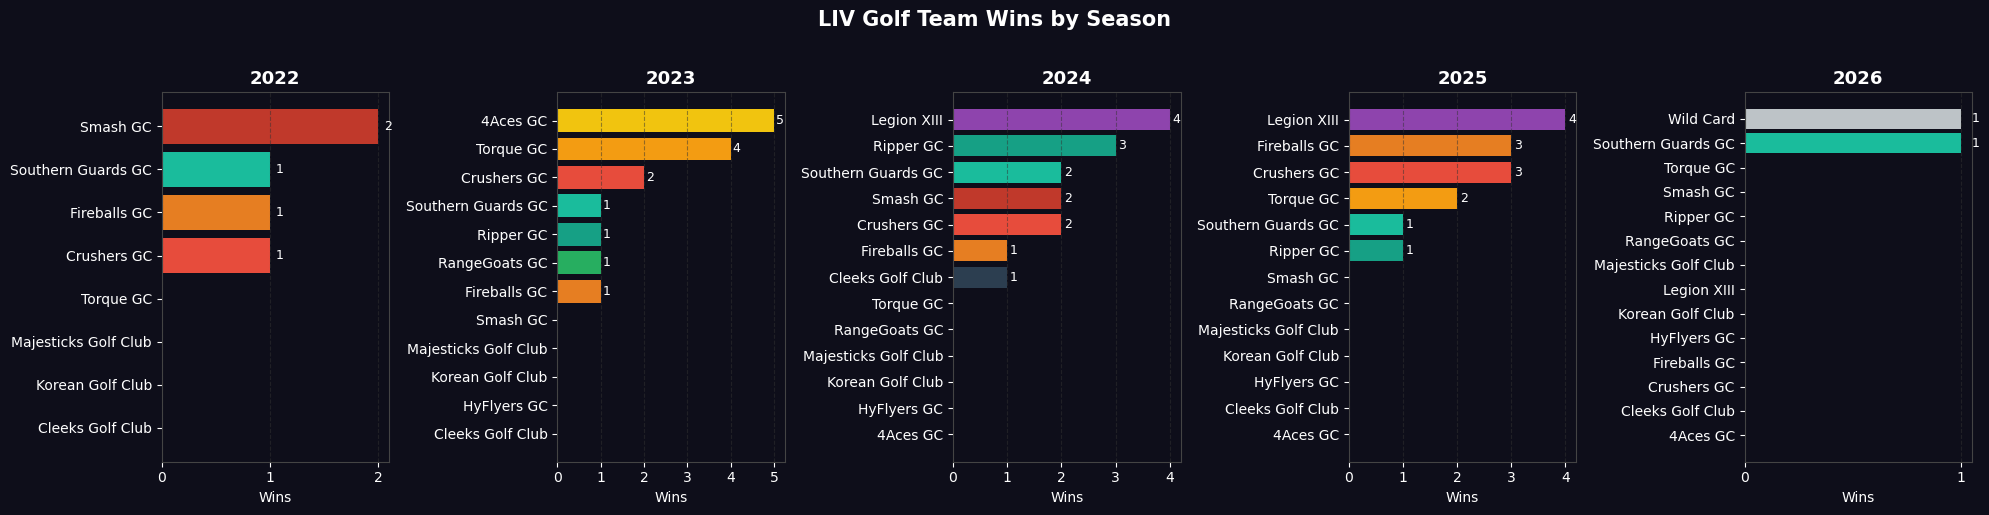

In [5]:
seasons = sorted(season_summary['year'].unique())
teams   = sorted(season_summary['team'].unique())

fig, axes = plt.subplots(1, len(seasons), figsize=(4 * len(seasons), 5), sharey=False)
if len(seasons) == 1:
    axes = [axes]

for ax, yr in zip(axes, seasons):
    yr_data = (
        season_summary[season_summary['year'] == yr]
        .sort_values('wins', ascending=True)
    )
    colors = [TEAM_COLORS.get(t, '#888') for t in yr_data['team']]
    bars = ax.barh(yr_data['team'], yr_data['wins'], color=colors, edgecolor='none')
    ax.set_xlabel('Wins')
    ax.set_title(str(yr), fontsize=13, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis='x')
    # Label bars
    for bar, val in zip(bars, yr_data['wins']):
        if val > 0:
            ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                    str(int(val)), va='center', fontsize=9)

fig.suptitle('LIV Golf Team Wins by Season', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'team_wins_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Avg team finish rank over time

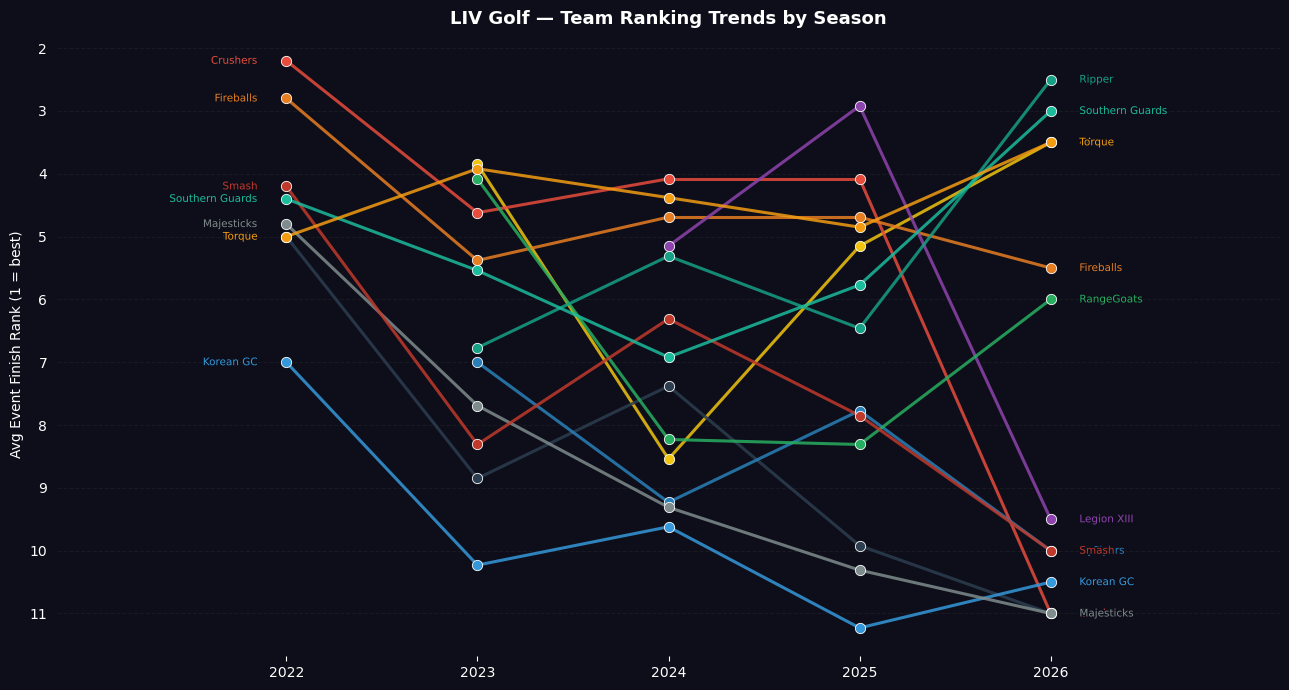

In [6]:
fig, ax = plt.subplots(figsize=(13, 7))

seasons_avail = sorted(season_summary['year'].unique())

for team in teams:
    tdata = season_summary[season_summary['team'] == team].sort_values('year')
    if len(tdata) < 2:
        continue
    color = TEAM_COLORS.get(team, '#888')
    xs = tdata['year'].values
    ys = tdata['avg_rank'].values

    # Draw curved segments between consecutive seasons via quadratic Bezier
    for i in range(len(xs) - 1):
        xA, yA = xs[i],   ys[i]
        xB, yB = xs[i+1], ys[i+1]
        t  = np.linspace(0, 1, 60)
        xm = (xA + xB) / 2
        bx = (1-t)**2 * xA + 2*(1-t)*t * xm + t**2 * xB
        by = (1-t)**2 * yA + 2*(1-t)*t * ((yA+yB)/2) + t**2 * yB
        ax.plot(bx, by, color=color, linewidth=2.2, alpha=0.85, solid_capstyle='round')

    ax.scatter(xs, ys, color=color, s=55, zorder=5, edgecolors='white', linewidth=0.6)

# Labels only on first and last season to avoid clutter
first_yr = seasons_avail[0]
last_yr  = seasons_avail[-1]

for team in teams:
    tdata = season_summary[season_summary['team'] == team].sort_values('year')
    if len(tdata) < 2:
        continue
    color = TEAM_COLORS.get(team, '#888')
    short = SHORT_NAMES.get(team, team)

    first_row = tdata[tdata['year'] == first_yr]
    if not first_row.empty:
        ax.text(first_yr - 0.15, first_row.iloc[0]['avg_rank'], short,
                ha='right', va='center', fontsize=7.5, color=color,
                path_effects=[pe.withStroke(linewidth=2, foreground='#0e0e1a')])

    last_row = tdata[tdata['year'] == last_yr]
    if not last_row.empty:
        ax.text(last_yr + 0.15, last_row.iloc[0]['avg_rank'], short,
                ha='left', va='center', fontsize=7.5, color=color,
                path_effects=[pe.withStroke(linewidth=2, foreground='#0e0e1a')])

ax.invert_yaxis()
ax.set_xticks(seasons_avail)
ax.set_xticklabels(seasons_avail)
ax.set_ylabel('Avg Event Finish Rank (1 = best)')
ax.set_title('LIV Golf — Team Ranking Trends by Season', fontsize=13, fontweight='bold')
ax.set_xlim(first_yr - 1.2, last_yr + 1.2)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(OUT_DIR / 'team_avg_rank_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Avg team score to par over time

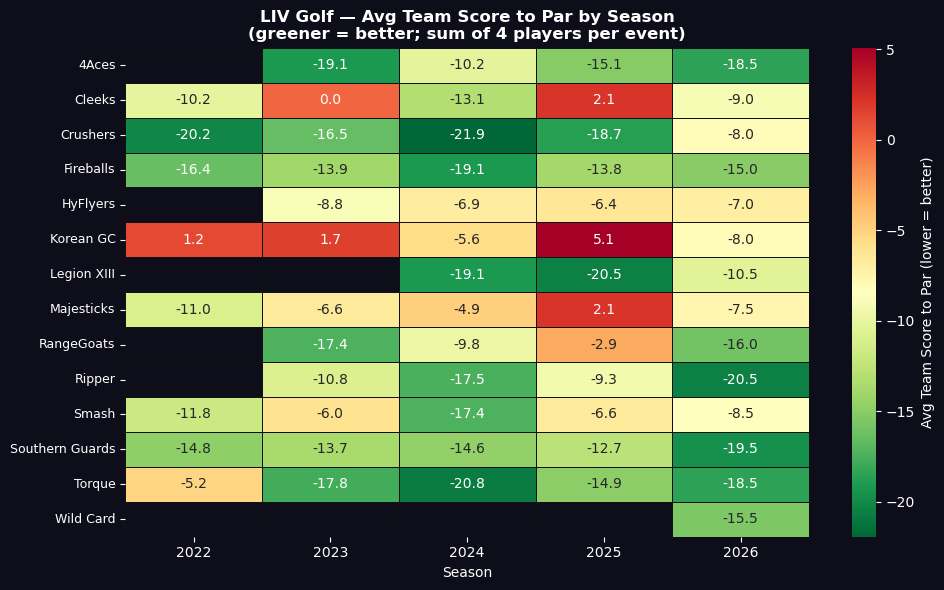

In [7]:
# Pivot: teams × seasons, value = avg team score to par
score_pivot = season_summary.pivot_table(
    index='team', columns='year', values='avg_score'
).sort_index()

score_pivot.index = [SHORT_NAMES.get(t, t) for t in score_pivot.index]

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    score_pivot,
    ax=ax,
    cmap='RdYlGn_r',        # reversed: more negative (better) = green
    annot=True, fmt='.1f',
    linewidths=0.5, linecolor='#111',
    cbar_kws={'label': 'Avg Team Score to Par (lower = better)'},
)

ax.set_title('LIV Golf — Avg Team Score to Par by Season\n'
             '(greener = better; sum of 4 players per event)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'team_score_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Within-team contribution analysis

In [8]:
# For each event, rank each player within their team (1 = best score)
df['within_team_rank'] = (
    df.groupby(['event_slug', 'team'])['total_to_par']
    .rank(method='min', ascending=True)
    .astype(int)
)

# Team size per event (usually 4, occasionally 3 if a player withdrew)
team_sizes = (
    df.groupby(['event_slug', 'team'])['playerName']
    .count()
    .rename('team_size')
    .reset_index()
)
df = df.merge(team_sizes, on=['event_slug', 'team'], how='left')

# Contribution stats per player per season
contribution = (
    df.groupby(['playerName', 'team', 'year'])
    .agg(
        events_played = ('event_slug',        'count'),
        avg_score     = ('total_to_par',       'mean'),
        avg_team_rank = ('within_team_rank',   'mean'),
        # anchor = % events as team's best scorer (rank 1)
        anchor_rate   = ('within_team_rank',   lambda x: (x == 1).mean()),
        # drag = % events as team's worst scorer (rank == team size)
        drag_rate     = ('within_team_rank',
                         lambda x: (x == df.loc[x.index, 'team_size']).mean()),
    )
    .reset_index()
)
contribution['avg_score']     = contribution['avg_score'].round(2)
contribution['avg_team_rank'] = contribution['avg_team_rank'].round(2)
contribution['anchor_rate']   = contribution['anchor_rate'].round(3)
contribution['drag_rate']     = contribution['drag_rate'].round(3)

# Use most recent season with a full schedule (>=10 events)
full_seasons = (
    contribution.groupby('year')['events_played'].max()
)
latest_yr = full_seasons[full_seasons >= 10].index.max()
contrib_latest = contribution[contribution['year'] == latest_yr].copy()

print(f'=== Within-team contribution — {latest_yr} season ({len(contrib_latest)} players) ===')
print(contrib_latest.sort_values(['team', 'avg_team_rank'])
      [['playerName', 'team', 'events_played', 'avg_score', 'avg_team_rank',
        'anchor_rate', 'drag_rate']].to_string(index=False))

=== Within-team contribution — 2025 season (63 players) ===
         playerName                 team  events_played  avg_score  avg_team_rank  anchor_rate  drag_rate
     Thomas Pieters             4Aces GC             13      -4.46           2.31        0.231      0.154
       Patrick Reed             4Aces GC             13      -4.85           2.38        0.385      0.231
  Harold Varner III             4Aces GC             13      -2.85           2.46        0.231      0.231
     Dustin Johnson             4Aces GC             13      -2.92           2.54        0.308      0.231
      Richard Bland     Cleeks Golf Club             13      -3.23           1.77        0.538      0.077
      Adrian Meronk     Cleeks Golf Club             13      -1.69           2.08        0.308      0.077
      Martin Kaymer     Cleeks Golf Club             13       0.00           2.31        0.308      0.077
  Frederik Kjettrup     Cleeks Golf Club             12       7.08           3.50        0.0

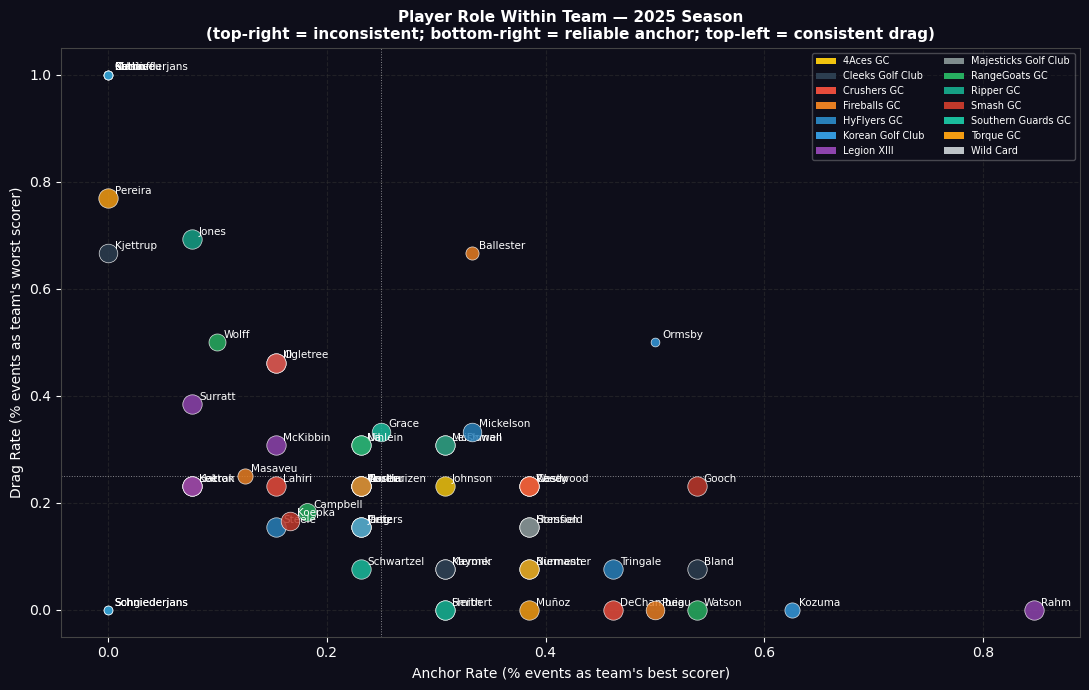

In [9]:
# Visualize: anchor rate vs drag rate bubble chart (latest season)
fig, ax = plt.subplots(figsize=(11, 7))

for _, row in contrib_latest.iterrows():
    color = TEAM_COLORS.get(row['team'], '#888')
    size  = max(row['events_played'] * 15, 40)
    ax.scatter(row['anchor_rate'], row['drag_rate'], s=size, color=color,
               alpha=0.85, edgecolors='white', linewidth=0.5, zorder=3)
    ax.annotate(
        row['playerName'].split()[-1],  # last name only
        xy=(row['anchor_rate'], row['drag_rate']),
        xytext=(5, 3), textcoords='offset points',
        fontsize=7.5, color='white'
    )

# Diagonal reference: anchor_rate + drag_rate ≈ 1 if only 2 players, varies with 4
ax.axhline(0.25, color='white', linewidth=0.7, linestyle=':', alpha=0.5)
ax.axvline(0.25, color='white', linewidth=0.7, linestyle=':', alpha=0.5)
ax.set_xlabel('Anchor Rate (% events as team\'s best scorer)')
ax.set_ylabel('Drag Rate (% events as team\'s worst scorer)')
ax.set_title(f'Player Role Within Team — {latest_yr} Season\n'
             '(top-right = inconsistent; bottom-right = reliable anchor; '
             'top-left = consistent drag)', fontsize=11, fontweight='bold')
ax.grid(True)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=TEAM_COLORS.get(t, '#888'), label=t) for t in sorted(teams)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=7,
          framealpha=0.3, ncol=2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'player_contribution_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Event result heatmap (teams × events)

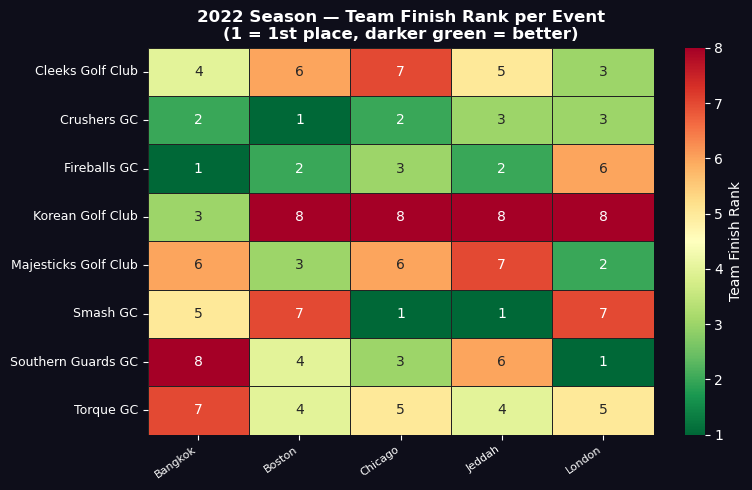

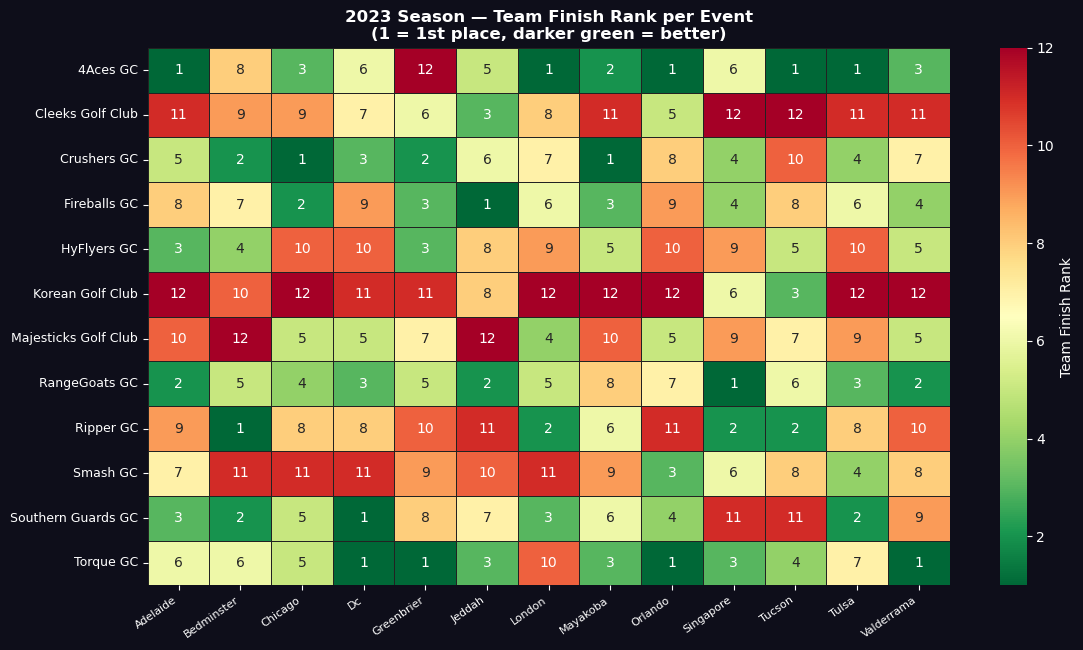

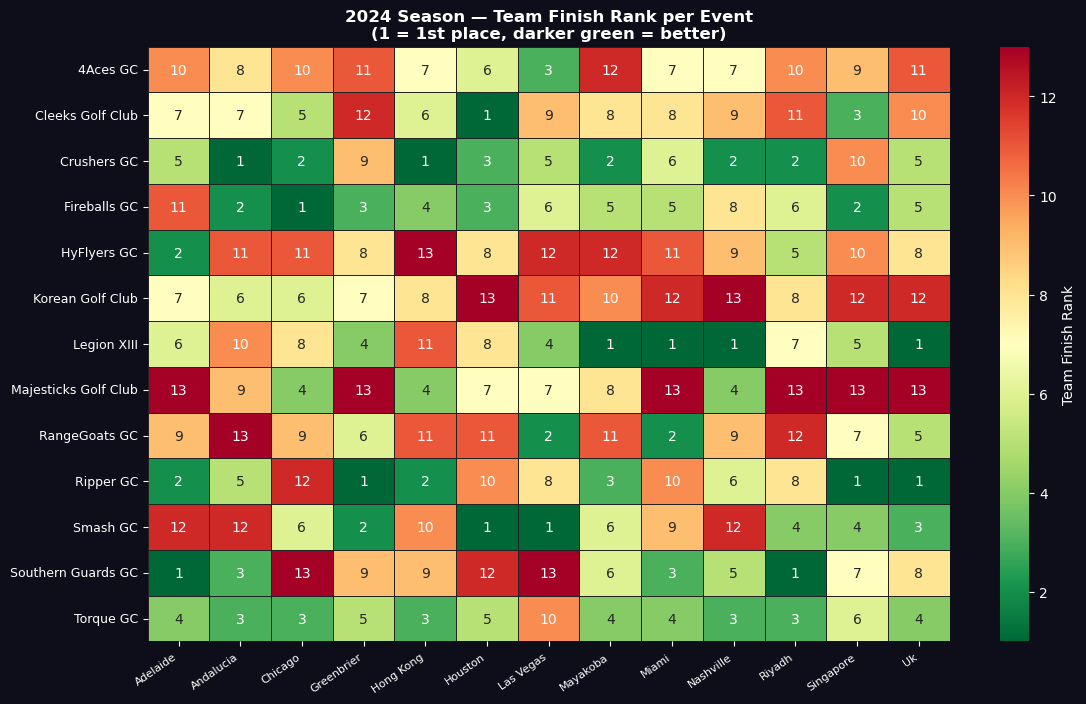

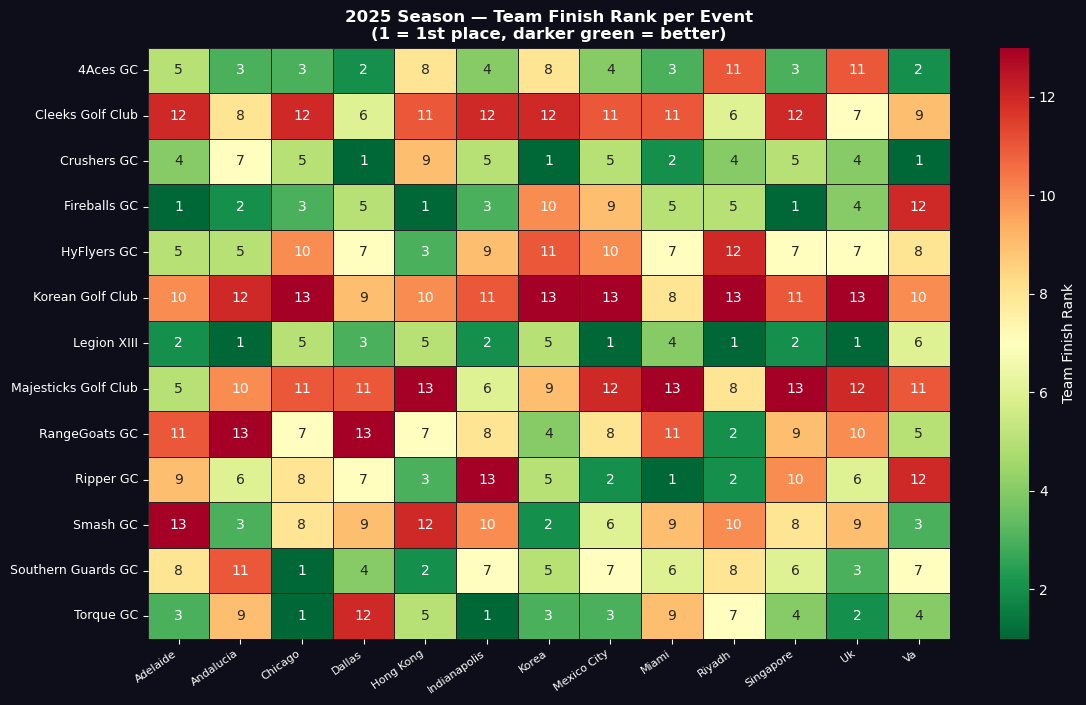

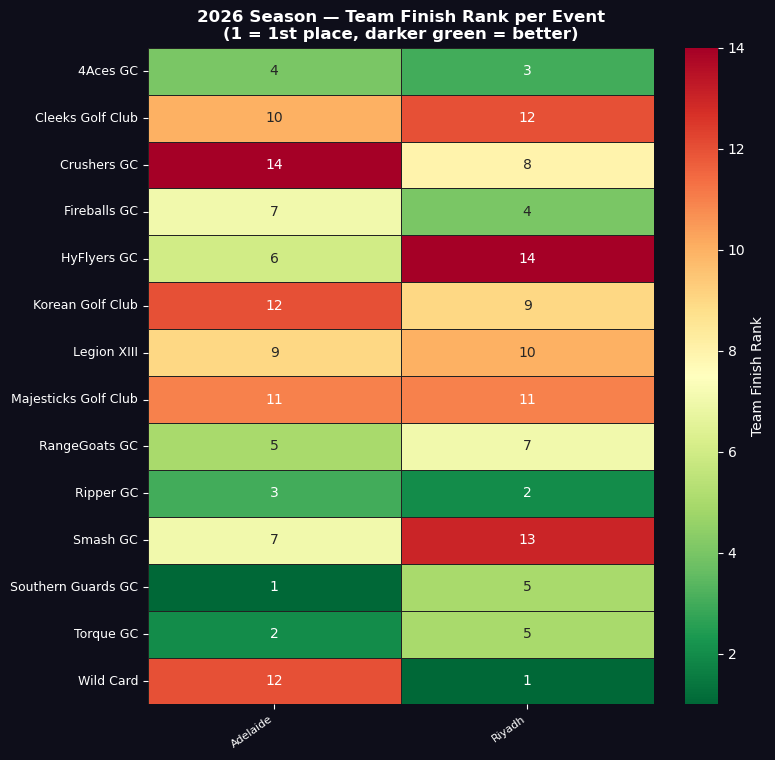

In [10]:
# One heatmap per season for readability
for yr in sorted(team_event['year'].unique()):
    yr_data = team_event[team_event['year'] == yr].copy()
    if yr_data.empty:
        continue

    # Pivot: rows = teams, cols = events (ordered chronologically)
    event_order = yr_data.groupby('event_slug')['year'].first().sort_values().index.tolist()
    pivot = yr_data.pivot_table(
        index='team', columns='event_slug', values='event_rank'
    ).reindex(columns=event_order)

    # Short event labels
    short_labels = [
        s.replace(f'-{yr}', '').replace('-', ' ').title()
        for s in event_order
    ]

    n_teams  = len(pivot)
    n_events = len(event_order)
    fig, ax = plt.subplots(figsize=(max(n_events * 0.9, 8), max(n_teams * 0.55, 5)))

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='RdYlGn_r',    # green = low rank (good), red = high rank (bad)
        vmin=1, vmax=n_teams,
        annot=True, fmt='.0f',
        linewidths=0.4, linecolor='#222',
        cbar_kws={'label': 'Team Finish Rank'},
        xticklabels=short_labels,
    )
    ax.set_title(f'{yr} Season — Team Finish Rank per Event\n'
                 '(1 = 1st place, darker green = better)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=35, ha='right', fontsize=8)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'event_heatmap_{yr}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Cell 10 — Save outputs

In [11]:
team_event.to_csv(OUT_DIR / 'team_event_results.csv', index=False)
season_summary.to_csv(OUT_DIR / 'team_season_summary.csv', index=False)
contribution.to_csv(OUT_DIR / 'player_team_contribution.csv', index=False)

print('Saved:')
print(f'  team_event_results.csv       — {len(team_event)} rows')
print(f'  team_season_summary.csv      — {len(season_summary)} rows')
print(f'  player_team_contribution.csv — {len(contribution)} rows')
print()
print('=== Quick stats ===')
print(f'Seasons covered:  {sorted(team_event["year"].unique())}')
print(f'Total events:     {team_event["event_slug"].nunique()}')
print(f'Total team-event rows: {len(team_event)}')
all_time_wins = season_summary.groupby('team')['wins'].sum().sort_values(ascending=False)
print('\nAll-time team wins:')
print(all_time_wins.to_string())

Saved:
  team_event_results.csv       — 562 rows
  team_season_summary.csv      — 60 rows
  player_team_contribution.csv — 287 rows

=== Quick stats ===
Seasons covered:  [2022, 2023, 2024, 2025, 2026]
Total events:     46
Total team-event rows: 562

All-time team wins:
team
Crushers GC             8
Legion XIII             8
Fireballs GC            6
Southern Guards GC      6
Torque GC               6
4Aces GC                5
Ripper GC               5
Smash GC                4
Cleeks Golf Club        1
RangeGoats GC           1
Wild Card               1
HyFlyers GC             0
Korean Golf Club        0
Majesticks Golf Club    0
